In [2]:
%load_ext autoreload
%autoreload 2

# Importing the modules
import os
os.environ['OMP_NUM_THREADS'] = '8' # Force the system to allocate 8 threads to OpenMP
os.environ['NGS_NUM_THREADS'] = '8' # Force NGSolve's internal task manager to use 8 threads
import ngsolve as ngs
ngs.SetNumThreads(8)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


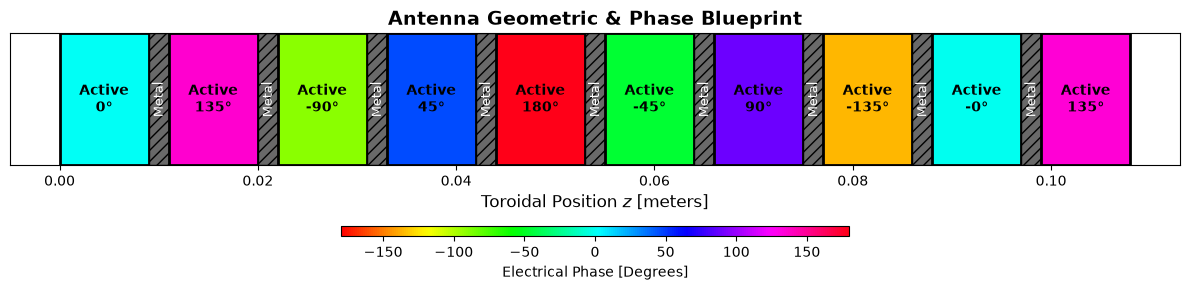

n_e = 5.00e+18 m^-3
n_acc(ne=5.00e+18 m^-3) = 1.21
In LHCoupling class: n_para: 2.8, n_perp_p: 1.35e+01+0.00e+00j, n_perp_m: 0.00e+00+2.54e+00j
Waveguide Medium set to: VACUUM


In [15]:
import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

import Antenna_Desc_n_Plot as antenna

geom_mode = "2D" # "1D" or "2D" 
box_medium = "PLASMA" # "VACUUM" or "PLASMA" 

antenna_grill = not None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.002, d_gap=0.010)
    antenna_grill.add_module(num_active=10, delta_phi_deg=135, is_PAM=False)

    instructions = antenna_grill.generate_mesh_instructions()
    antenna.plot_antenna_blueprint(instructions)

solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, geom_mode, box_medium, antenna_grill)

In [16]:
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium)

geom_mode: 2D
box_medium: PLASMA
[!] MEDIUM = PLASMA, Lx_pml is set based on lambda_perp_p
==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 1.81e-02m,    Lx_tot: 6.81e-02m
Lx_wg = 3.00e-02m
Lz_antenna: 1.08e-01m, Lz_wall: 2.00e-02m
Lz_plasma: 1.08e-01m, Lz_pml: 2.93e-02m, Lz_tot: 2.07e-01m
==== 
n_∥: 2.8,   λ_∥: 2.93e-02m 
n_⟂⁺:13.46+0.00j, λ_⟂⁺: 6.02e-03m 
n_⟂-:0.00+2.54j, λ_⟂⁻: 3.18e-02m
==== 
n_index_meshing: 13.46 
λ_meshing: 6.02e-03m 
maxh_plasma: 7.52e-04m
==== 
ppw_pml: 20.0 
Sx_norm:1.41e+00, maxh_pml_radial: 2.13e-04 
Sz_norm_max: 1.41e+00, maxh_pml_toroidal: 2.13e-04 
maxh_pml_corner: 1.50e-04
[DOMAIN 2D DEFINED AND GLUED]
[MESH GENERATED !]
==== 
#DoFs = 1791977
len(instruction): 19
z_start: 0.02, z_end: 0.028999999999999998, E_val: (10+0j)
z_start: 0.031, z_end: 0.04, E_val: (-7.071067811865475+7.0710678118654755j)
z_start: 0.042, z_end: 0.051000000000000004, E_val: (-1.8369701987210296e-15-10j)
z_start: 0.053000000000000005, z_end: 0.062000000000000006, E_val: (7.071067811865477+7.0

In [5]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260703_144128
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260703_144128


--- Extracting 2D Wave Map ---
Lz_plasma_src: 0.108, Lz_wall: 0.020, Lz_pml: 0.029, Lz_tot: 0.207
Bornes géométriques fixées
  --> Pure Multithreaded C++ vectorized interpolation...
n_e = 5.00e+18 m^-3
n_acc(ne=5.00e+18 m^-3) = 1.21
In LHCoupling class: n_para: 2.8, n_perp_p: 1.35e+01+0.00e+00j, n_perp_m: 0.00e+00+2.54e+00j
Waveguide Medium set to: VACUUM
n_e = 5.00e+18 m^-3
n_acc(ne=5.00e+18 m^-3) = 1.21
PP_run_n_save: n_para: 2.8, n_perp_p: 1.35e+01+0.00e+00j, n_perp_m: 0.00e+00+2.54e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260703_144128/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui

PRINT H5 METADATA:
 Lx_plasma: 5.00e-02
 Lx_pml: 1.81e-02
 Lx_tot: 6.81e-02
 Lz_plasma: 1.08e-01
 Lz_pml: 2.93e-02
 Lz_tot: 2.07e-01
 P_in_net: 5.18e-03
 P_out_Radial: 8.20e-06
 P_out_Toroidal: 3.96e-03
 eta_pred_R: 3.49e-06
 eta_pred_T: 1.52e-02
 eta_sim_R: 9.70e-01
 eta_sim_T: 8.95e-01
 k_para: -2.14e+02
 k_perp_p: (-1043.81060

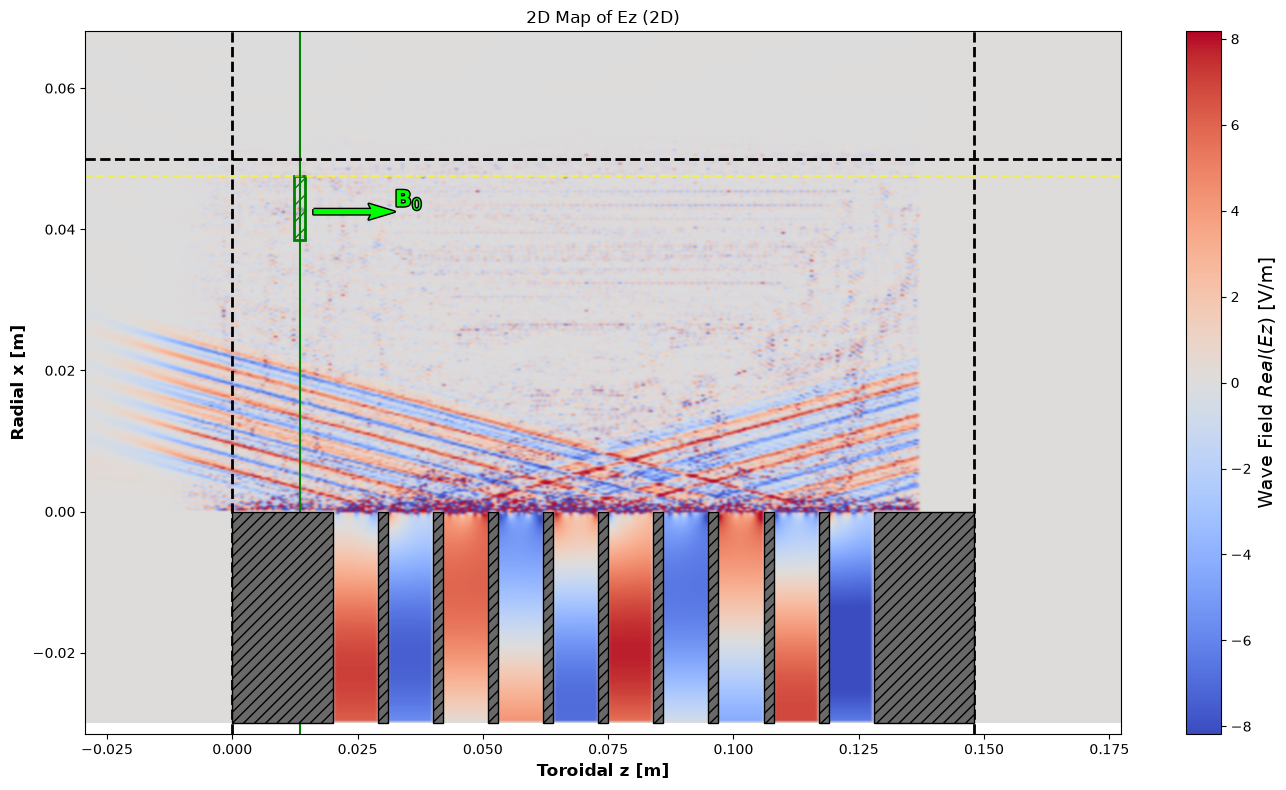

In [17]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, geom_mode, box_medium, antenna_grill, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
Lx_wg = cfg.DOMAIN.get('Lx_wg', 0.03)
Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, geom_mode, component='Ez', value_type='real',
                        antenna_grill=antenna_grill, Lx_wg=Lx_wg, Lz_wall=Lz_wall, plot_poynting=False, show_windows=True, Poynting_box=False)

/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/PP_Plot_and_Load.py:250: RuntimeWarning: invalid value encountered in divide
  power_spectrum /=np.max(power_spectrum) # normalize to 1.0


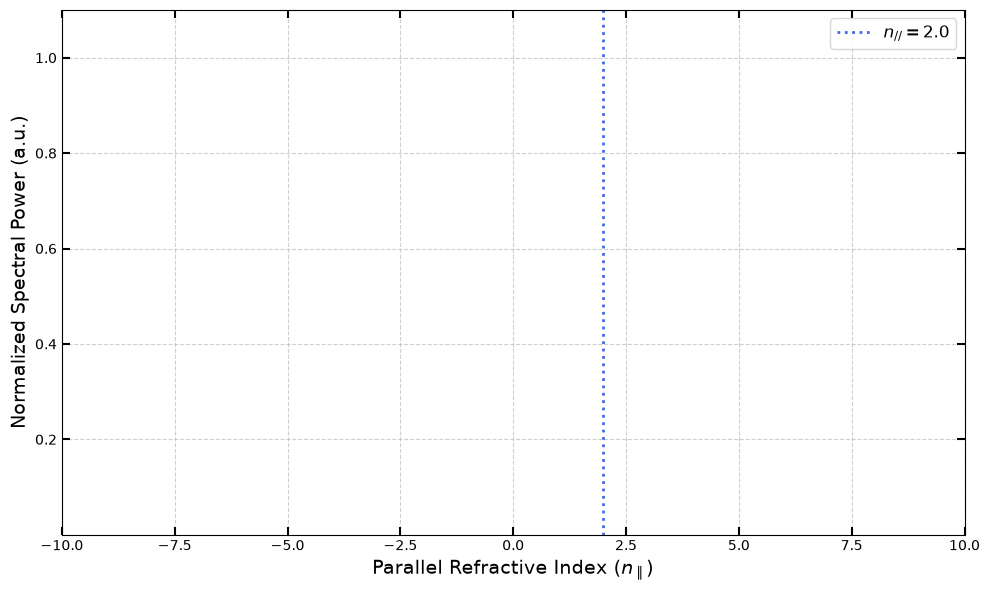

In [ ]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, geom_mode, x_eval=0.01)


In [7]:
import sweep_param_functions as spf

# db_filepath = spf.generate_1D_radial_pml_database(cfg.__dict__, geom_mode, box_medium,save_dir="Simulation_Results")

In [8]:
import sweep_param_functions as spf
# db_filepath
# Vide Radial 1D 40 pts: Simulation_Results/PML_1D_VACUUM_40pts.h5
# PLASMA Radial 1D n_para = 2, 5 avec 40pts: Simulation_Results/1D_PLASMA_40pts.h5
# PLASMA radial 1D n_para = 20, 50 avec 20pts: Simulation_Results/1D_PLASMA_n_para_20_et_50_20pts.h5
# PLASMA radial 1D n_para = 3 avec 20pts: Simulation_Results/1D_PLASMA_n_para=3_Lx_pml=2_to_4_5_20pts.h5
# PLASMA radial 1D n_para=2.5 to 3.5 20pts: 1D_PLASMA_n_para=2_5_to_3_5__Lx_pml=2_to4_5_20pts.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_10_to_60.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_1_18.h5
# Simulation_Results/1D_PLASMA_n_para=2_3_5_40pts.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_6_to_20_40pts.h5

# Simulation_Results/PML_Radial_1D_Database_20260630_175333.h5 (A RE-TRAVAILLER)

# Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-10_-2__2_10.h5
# Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-2_-1_25_and_1_25_2


# Simulation_Results/1D_VACUUM_n_para=0_40pts.h5

# spf.plot_sweeps_all_npara("Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5")

In [9]:
import sweep_param_functions as spf
main_files = ["Simulation_Results/1D_PLASMA_40pts.h5", 
        "Simulation_Results/1D_PLASMA_n_para_20_et_50_20pts.h5"]
inset_files = ["Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5"]    
params_to_plot = ['Sx_r', 'Sx_im', 'px', 'Lx_pml_ratio']
    
spf.plot_publication_gamma_with_inset(main_files, inset_files, params_to_plot)

--- Generating Publication Figures with Multi-Curve Insets ---
[!] Warning reading Simulation_Results/1D_PLASMA_40pts.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/1D_PLASMA_40pts.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
[!] Warning reading Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/sweep_param_functions.py:894: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_inset.legend(bbox_to_anchor=(.4, .3), fontsize=8, ncol=2, framealpha=0.9)


  -> Figure saved: Publication_GammaR_vs_Sx_r_with_Multi_Inset.svg
[!] Warning reading Simulation_Results/1D_PLASMA_40pts.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/1D_PLASMA_40pts.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
[!] Warning reading Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
  -> Figure saved: Publication_GammaR_vs_Sx_im_with_Multi_Inset.svg
[!] Warning reading Simulation_Results/1D_PLASMA_40pts.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/1D_PLASMA_40pts.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
[!] Warning reading Simulation_Results/PML_Radial_1D_Databas

In [10]:
# import sweep_param_functions as spf
# dataset_files = ["Simulation_Results/1D_VACUUM_n_para=0_40pts.h5", "Simulation_Results/1D_PLASMA_40pts.h5",
#                  "Simulation_Results/1D_PLASMA_n_para_20_et_50_20pts.h5"]

#     # 1. Check Mesh Stability
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['ppw_medium'])
    
#     # 2. Prove Global Independence across the Spectrum
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['n_para'])
    
#     # 3. Prove PML parameter decoupling
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['Sx_im', 'px', 'Lx_pml_ratio'])

In [11]:
# spf.plot_vacuum_pml_validation("Simulation_Results/1D_VACCUM_n_para=0_40pts.h5")

In [12]:
file_list = ["Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_10_to_60.h5", 
"Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_1_18.h5", "Simulation_Results/1D_PLASMA_n_para=2_ppw_6_to_20_40pts.h5"]

# file_list = ["Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-10_-2__2_10.h5", 
#              "Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-2_-1_25_and_1_25_2.h5"]
import sweep_param_functions as spf
# spf.plot_concatenated_general_sweeps(file_list)

In [13]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.df_doe, problem_dict = sob_sur.generate_sobol_doe(N_base=2)
print("\nFirst 5 rows of the Physical DoE:")
print(sob_sur.df_doe.head())

KeyboardInterrupt: 

In [ ]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.run_phase2_batch_multiprocess("DoE_Sobol_PML_6D.csv", max_workers=8)

--- Starting Phase 2: Multiprocessed FEM Batch ---
[*] Allocating strictly 8 CPU cores to protect VM resources.
[*] Found 28 remaining simulations to execute.


n_e = 5.29e+17 m^-3
n_acc(ne=5.29e+17 m^-3) = 1.06
In LHCoupling class: n_para: 2.1, n_perp_p: 2.65e+00+0.00e+00j, n_perp_m: 0.00e+00+1.83e+00j
n_e = 5.29e+17 m^-3
n_acc(ne=5.29e+17 m^-3) = 1.06
n_e = 5.29e+17 m^-3
n_acc(ne=5.29e+17 m^-3) = 1.06
In LHCoupling class: n_para: 2.1, n_perp_p: 2.65e+00+0.00e+00j, n_perp_m: 0.00e+00+1.83e+00j
geom_mode: 1D
box_medium: PLASMA
[!] MEDIUM = PLASMA, Lx_pml is set based on lambda_perp_p
==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 9.16e-02m,    Lx_tot: 1.42e-01m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.17e-01m, Lz_pml: 0.00e+00m, Lz_tot: 1.17e-01m
==== 
n_∥: 2.1,   λ_∥: 3.89e-02m 
n_⟂⁺:2.65+0.00j, λ_⟂⁺: 3.05e-02m 
n_⟂-:0.00+1.83j, λ_⟂⁻: 4.43e-02m
==== 
n_index_meshing: 2.65 
λ_meshing: 3.05e-02m 
maxh_plasma: 3.82e-03m
n_e = 6.17e+17 m^-3
n_acc(ne=6.17e+17 m^-3) = 1.07
In LHCoupling class: n_para: 2.8, n_perp_p: 4.27e+00+0.00e+00j, n_perp_m: 0.00e+00+2.64e+00j
n_e = 6.17e+17 m^-3
n_acc(ne=6.17e+17 m^-3) = 1.07
n_e = 6.17e

In [15]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.train_surrogate_models("DoE_Sobol_PML_6D.csv")

KeyError: '__reduce_cython__'

In [16]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.compute_sobol_indices()

KeyError: '__reduce_cython__'

In [ ]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.robust_pml_optimization(max_allowed_dofs=15000)

--- Phase 5: Robust Weighted Optimization ---
[*] Launching Differential Evolution Optimizer...
[*] Constraint: Max DoFs = 15000
[*] Weighting: Exponential decay favoring low n_parallel
differential_evolution step 1: f(x)= 183697406.30616406
differential_evolution step 2: f(x)= 183697406.30616406
differential_evolution step 3: f(x)= 175005730.13541785
differential_evolution step 4: f(x)= 175005730.13541785
differential_evolution step 5: f(x)= 162195256.09970805
differential_evolution step 6: f(x)= 162195256.09970805
differential_evolution step 7: f(x)= 157533492.82425916
differential_evolution step 8: f(x)= 157213958.58246583
differential_evolution step 9: f(x)= 157122445.65386775
differential_evolution step 10: f(x)= 153283031.58891198
differential_evolution step 11: f(x)= 153283031.58891198
differential_evolution step 12: f(x)= 152968392.96920878
differential_evolution step 13: f(x)= 152968392.96920878
differential_evolution step 14: f(x)= 151866500.25260866
differential_evolution st

In [ ]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import joblib

# Import your actual FEM solver
from config_dict import cfg as base_cfg 
from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

def final_validation_sweep(opt_params, ne_test=3e18):
    """
    Validates the Phase 5 optimal parameters by running the real NGSolve FEM 
    across the entire n_parallel spectrum and comparing it to the Surrogate model.
    """
    print("--- Phase 6: Final Ground-Truth Validation ---")
    
    # 1. Extract the optimal parameters from Phase 5
    Sx_r_opt, Sx_im_opt, px_opt, Lx_ratio_opt = opt_params
    print(f"[*] Testing Universal PML: Sx_r={Sx_r_opt:.2f}, Sx_im={Sx_im_opt:.2f}, px={px_opt:.2f}, L_ratio={Lx_ratio_opt:.2f}")
    
    # 2. Load the trained surrogate to compare predictions
    try:
        gpr_gamma = joblib.load('surrogate_gamma.pkl')
        scaler = joblib.load('feature_scaler.pkl')
    except Exception as e:
        print("[!] Warning: Surrogate models not found for comparison.")
        gpr_gamma = None
        
    # 3. Define the validation spectrum
    n_para_sweep = np.linspace(2.0, 80.0, 20)
    
    real_gamma_list = []
    pred_gamma_list = []
    
    for n_para in n_para_sweep:
        print(f"  -> Solving FEM for n_para = {n_para:.1f} ...")
        
        # --- Real FEM Execution ---
        scan_cfg = copy.deepcopy(base_cfg)
        scan_cfg['PML']['Sx_r'] = Sx_r_opt
        scan_cfg['PML']['Sx_im'] = Sx_im_opt
        scan_cfg['PML']['px'] = px_opt
        scan_cfg['PLASMA']['ne_constant'] = ne_test
        scan_cfg['WAVE']['n_para'] = n_para
        
        # Geometry scaling
        temp_solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, geom_mode="1D", box_medium="PLASMA", antenna_grill=None)
        _, n_perp_p, _ = temp_solver.compute_physics_parameters()
        lambda_perp = scan_cfg['WAVE']['lambda0'] / np.abs(n_perp_p.real)
        scan_cfg['DOMAIN']['Lx_pml'] = Lx_ratio_opt * lambda_perp
        scan_cfg['DOMAIN']['Lx_tot'] = scan_cfg['DOMAIN']['Lx_plasma'] + scan_cfg['DOMAIN']['Lx_pml']
        del temp_solver
        
        # Solve
        try:
            solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, geom_mode="1D", box_medium="PLASMA", antenna_grill=None)
            mesh = solver.build_mesh_with_PMLs()
            solver.build_physics_Stix_B_field()
            _, Gamma_R, _, _ = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, "1D", "PLASMA")
            real_gamma_list.append(Gamma_R)
        except Exception as e:
            print(f"     [!] FEM Failed: {e}")
            real_gamma_list.append(np.nan)
            
        # --- Surrogate Prediction ---
        if gpr_gamma is not None:
            # Build the 6D feature vector exactly as in Phase 3
            X_test = np.array([[Sx_r_opt, Sx_im_opt, px_opt, Lx_ratio_opt, np.log10(ne_test), np.log10(n_para)]])
            X_scaled = scaler.transform(X_test)
            pred_log_gamma = gpr_gamma.predict(X_scaled)[0]
            pred_gamma_list.append(10 ** pred_log_gamma)
            
    # 4. Plot the Validation Results
    plt.figure(figsize=(9, 6))
    
    plt.plot(n_para_sweep, real_gamma_list, marker='o', linestyle='-', color='black', lw=2, label='True FEM Physics')
    
    if gpr_gamma is not None:
        plt.plot(n_para_sweep, pred_gamma_list, marker='x', linestyle='--', color='red', lw=2, label='Surrogate Prediction')
        
    plt.yscale('log')
    plt.xlabel(r"Parallel Refractive Index ($n_\parallel$)", fontweight='bold')
    plt.ylabel(r"Reflection Coefficient ($\Gamma_R$)", fontweight='bold')
    plt.title(f"Universal PML Performance Validation ($n_e = {ne_test:.1e}$)")
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig("Phase6_Final_Validation.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    # Replace this array with the output from Phase 5 once your 3500-run batch finishes
    # [Sx_r, Sx_im, px, Lx_ratio]
    dummy_optimal_params = [1.5, 3.0, 2.5, 1.0] 
    final_validation_sweep(dummy_optimal_params, ne_test=3e18)